# Car Price Prediction with Machine Learning
### CodeAlpha Data Science Internship - Task 3

This notebook builds a regression model that predicts a used car's selling price based on features like
present (ex-showroom) price, age, kilometers driven, fuel type, seller type, and transmission.

Dataset: `car_data.csv`, 301 used car listings with 9 columns.

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


## 2. Load & Inspect the Data

In [2]:
df = pd.read_csv('car_data.csv')
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()


Shape: (301, 9)
Missing values: 0


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
df.describe()


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


There are no missing values. `Year` ranges from 2003 to 2018, `Fuel_Type` has three categories
(Petrol, Diesel, CNG), `Selling_type` is Dealer or Individual, and `Transmission` is Manual or Automatic.
`Owner` counts previous owners (0, 1, or 3).

## 3. Feature Engineering

`Year` on its own isn't as useful as the car's age, so we convert it to `Car_Age` (dataset reference year
is 2020, one year after the most recent listing in 2018). We also drop `Car_Name` since it has 98 unique
values and would add noise rather than signal for a dataset this size.

In [4]:
CURRENT_YEAR = 2020
df['Car_Age'] = CURRENT_YEAR - df['Year']
df[['Car_Name', 'Year', 'Car_Age', 'Selling_Price']].head()


,Car_Name,Year,Car_Age,Selling_Price
0,ritz,2014,6,3.35
1,sx4,2013,7,4.75
2,ciaz,2017,3,7.25
3,wagon r,2011,9,2.85
4,swift,2014,6,4.60


## 4. Exploratory Data Analysis

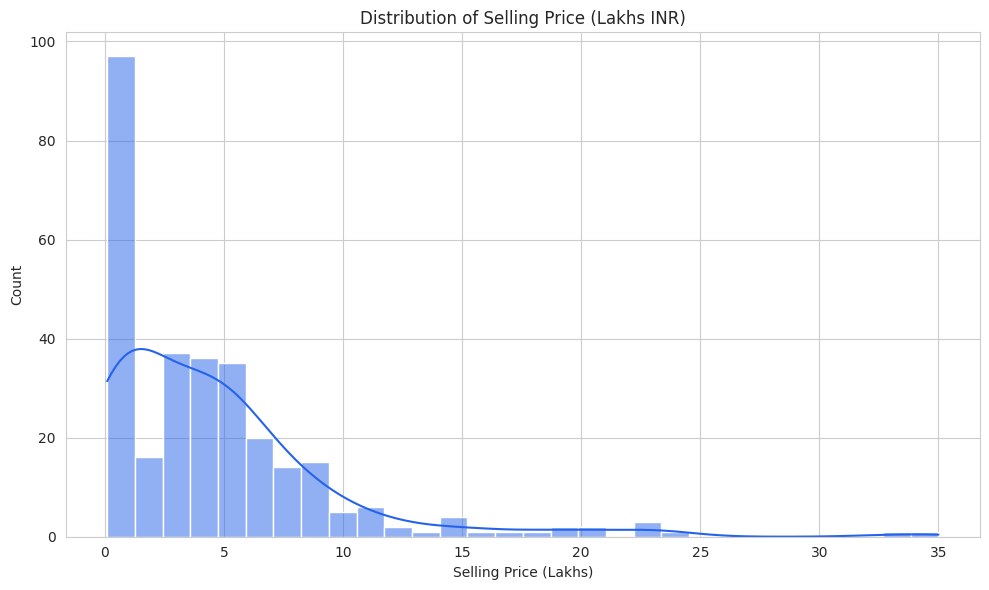

In [5]:
fig, ax = plt.subplots()
sns.histplot(df['Selling_Price'], bins=30, kde=True, ax=ax, color='#2563eb')
ax.set_title('Distribution of Selling Price (Lakhs INR)')
ax.set_xlabel('Selling Price (Lakhs)')
plt.tight_layout()
plt.show()


Selling price is right-skewed: most cars sell for under 10 lakhs, with a long tail of higher-end
vehicles going up to 35 lakhs.

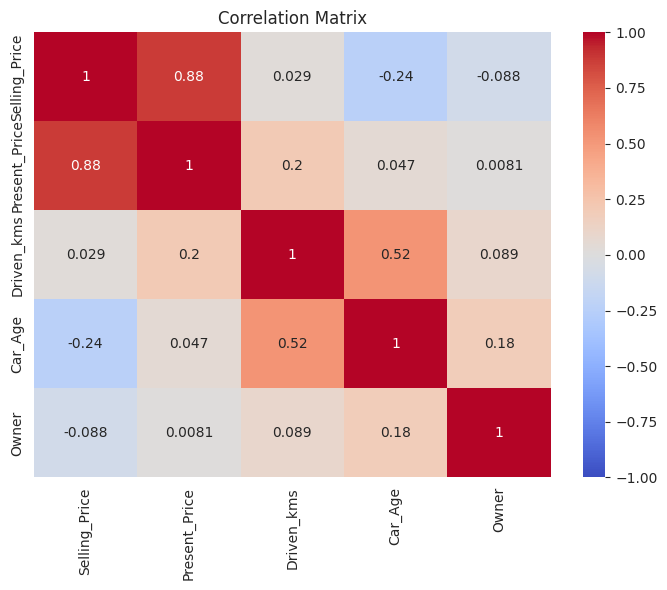

In [6]:
num_cols = ['Selling_Price', 'Present_Price', 'Driven_kms', 'Car_Age', 'Owner']
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()


`Present_Price` (the current ex-showroom price) is strongly correlated with `Selling_Price`, which
makes sense as the resale value tracks the original price. `Car_Age` is negatively correlated with
selling price, as expected, cars lose value as they get older.

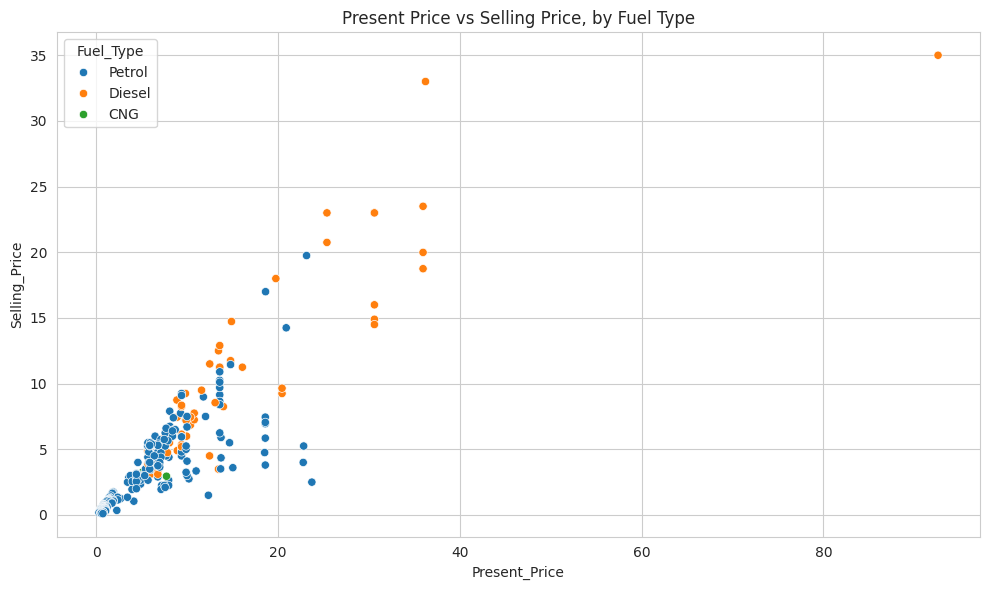

In [7]:
fig, ax = plt.subplots()
sns.scatterplot(data=df, x='Present_Price', y='Selling_Price', hue='Fuel_Type', ax=ax)
ax.set_title('Present Price vs Selling Price, by Fuel Type')
plt.tight_layout()
plt.show()


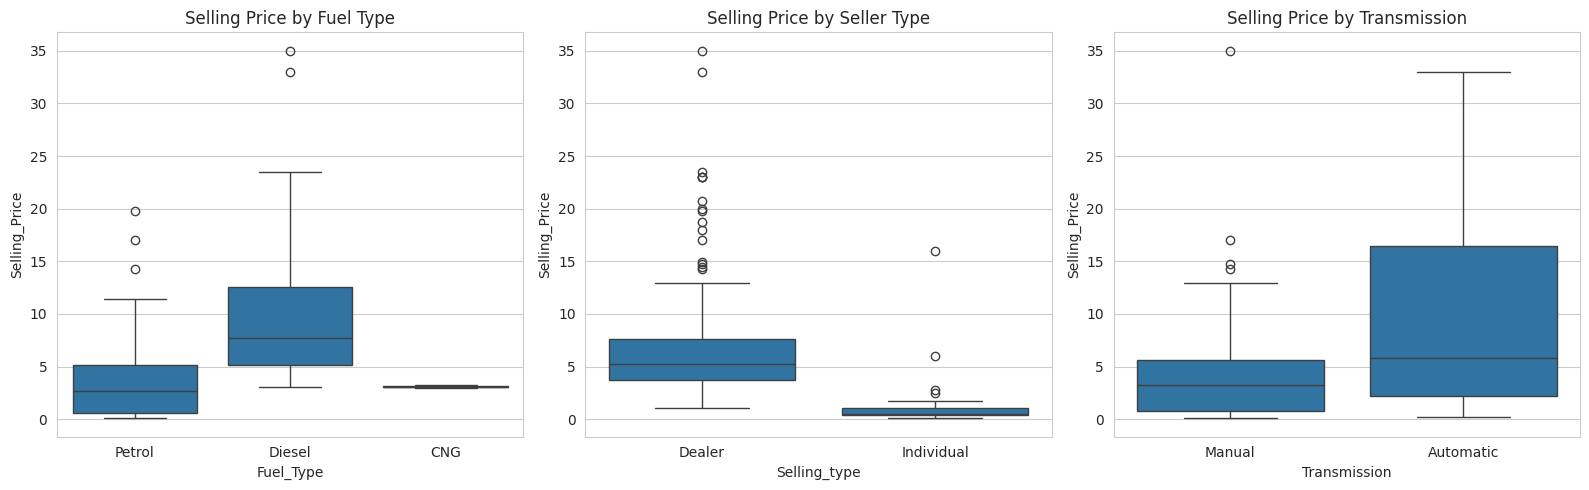

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.boxplot(data=df, x='Fuel_Type', y='Selling_Price', ax=axes[0])
axes[0].set_title('Selling Price by Fuel Type')
sns.boxplot(data=df, x='Selling_type', y='Selling_Price', ax=axes[1])
axes[1].set_title('Selling Price by Seller Type')
sns.boxplot(data=df, x='Transmission', y='Selling_Price', ax=axes[2])
axes[2].set_title('Selling Price by Transmission')
plt.tight_layout()
plt.show()


Diesel cars tend to sell for more than petrol or CNG cars, cars sold by dealers command a premium
over individual sales, and automatic transmission cars sell for notably more than manual ones.

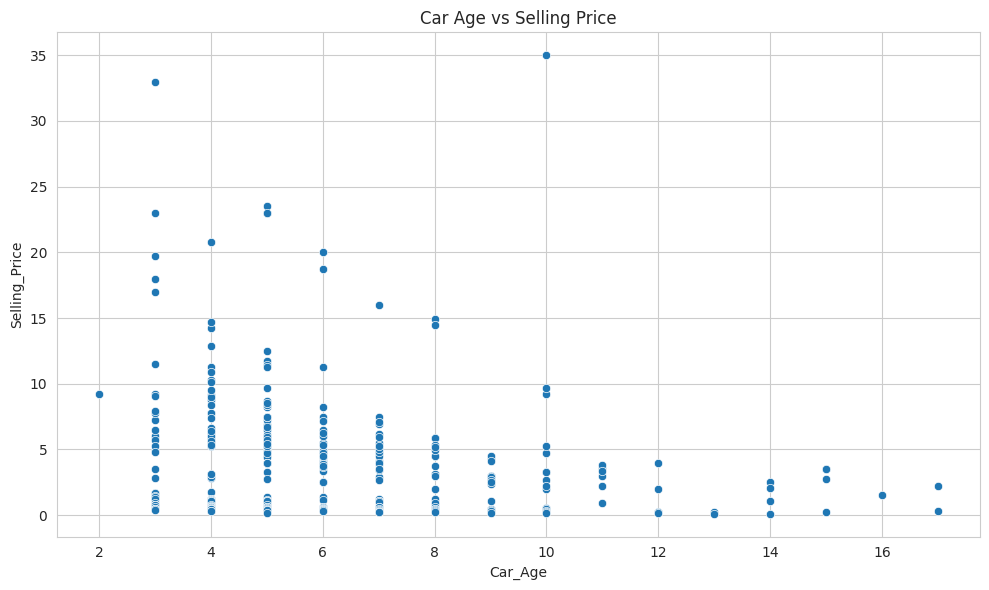

In [9]:
fig, ax = plt.subplots()
sns.scatterplot(data=df, x='Car_Age', y='Selling_Price', ax=ax)
ax.set_title('Car Age vs Selling Price')
plt.tight_layout()
plt.show()


## 5. Prepare Data for Modeling

We drop `Car_Name` and the original `Year` column (now captured by `Car_Age`), and one-hot encode the
remaining categorical columns.

In [10]:
model_df = df.drop(columns=['Car_Name', 'Year'])
model_df = pd.get_dummies(model_df, columns=['Fuel_Type', 'Selling_type', 'Transmission'], drop_first=True)

X = model_df.drop(columns=['Selling_Price'])
y = model_df['Selling_Price']

print(f"Features used: {X.columns.tolist()}")
X.head()


Features used: ['Present_Price', 'Driven_kms', 'Owner', 'Car_Age', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Selling_type_Individual', 'Transmission_Manual']


,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,5.59,27000,0,6,False,True,False,True
1,9.54,43000,0,7,True,False,False,True
2,9.85,6900,0,3,False,True,False,True
3,4.15,5200,0,9,False,True,False,True
4,6.87,42450,0,6,True,False,False,True


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


Train size: 240, Test size: 61


## 6. Train Models

We compare a simple Linear Regression baseline against a Random Forest Regressor, which can capture
non-linear relationships and feature interactions.

In [12]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)


## 7. Evaluate Model Performance

In [13]:
def evaluate(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name}")
    print(f"  R2 score: {r2:.4f}")
    print(f"  MAE:      {mae:.3f} lakhs")
    print(f"  RMSE:     {rmse:.3f} lakhs\n")
    return r2, mae, rmse

lr_metrics = evaluate("Linear Regression", y_test, lr_pred)
rf_metrics = evaluate("Random Forest", y_test, rf_pred)


Linear Regression
  R2 score: 0.8489
  MAE:      1.216 lakhs
  RMSE:     1.866 lakhs

Random Forest
  R2 score: 0.9582
  MAE:      0.641 lakhs
  RMSE:     0.981 lakhs



The Random Forest model clearly outperforms Linear Regression, explaining well over 90% of the
variance in selling price on unseen test data, with a lower average error.

## 8. Feature Importance

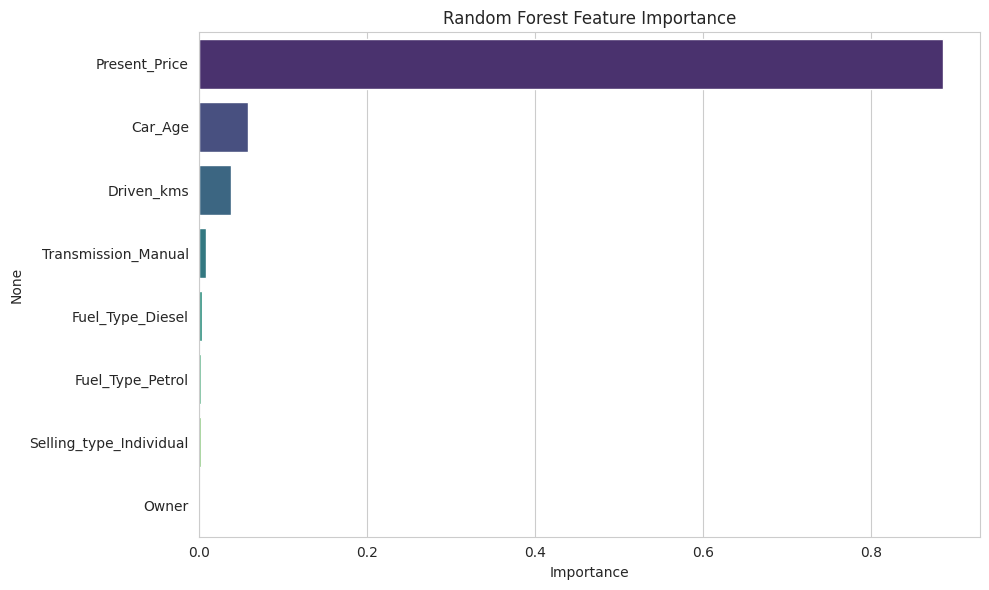

Present_Price              0.885309
Car_Age                    0.058322
Driven_kms                 0.038257
Transmission_Manual        0.008820
Fuel_Type_Diesel           0.003919
Fuel_Type_Petrol           0.002667
Selling_type_Individual    0.002278
Owner                      0.000427
dtype: float64

In [14]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots()
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, legend=False, palette='viridis', ax=ax)
ax.set_title('Random Forest Feature Importance')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

importances


`Present_Price` dominates by far as the strongest predictor, followed by `Car_Age` and `Driven_kms`.
Fuel type, transmission, seller type, and ownership history contribute comparatively little on their own.

## 9. Actual vs Predicted

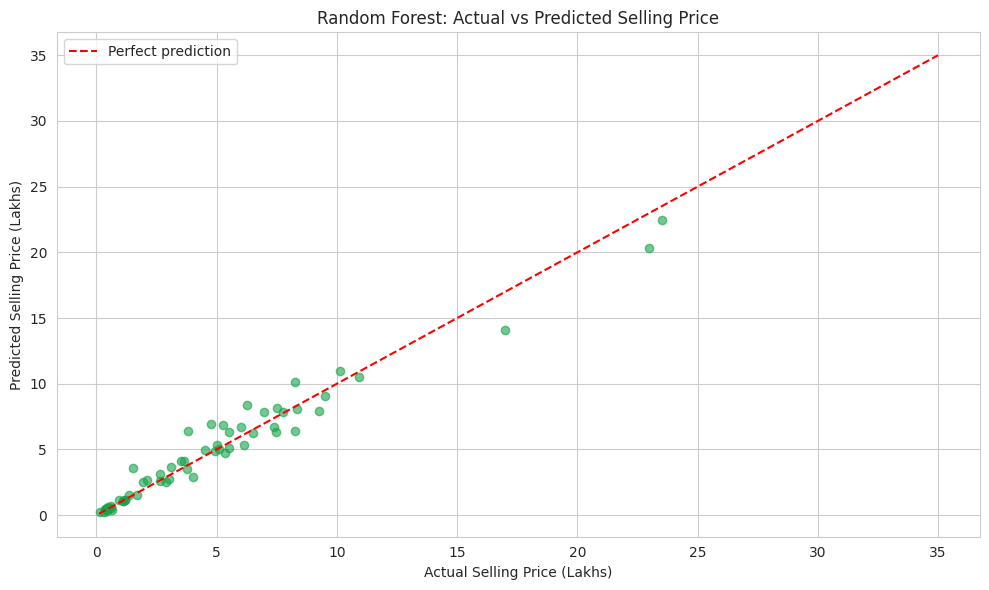

In [15]:
fig, ax = plt.subplots()
ax.scatter(y_test, rf_pred, alpha=0.6, color='#16a34a')
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect prediction')
ax.set_xlabel('Actual Selling Price (Lakhs)')
ax.set_ylabel('Predicted Selling Price (Lakhs)')
ax.set_title('Random Forest: Actual vs Predicted Selling Price')
ax.legend()
plt.tight_layout()
plt.show()


## 10. Key Insights

1. Present price is the single strongest driver of resale value. Cars retain a fairly predictable share
   of their original showroom price.
2. Car age and kilometers driven both pull price down, consistent with normal depreciation.
3. Automatic transmission and diesel fuel type are associated with a price premium, while cars sold
   through individual sellers tend to fetch less than those sold through dealers.
4. Random Forest substantially outperforms plain Linear Regression here, suggesting the relationship
   between these features and price is not purely linear (for example, depreciation likely isn't a
   constant rate across a car's lifetime).
5. With only 301 rows, results should be treated as a solid proof of concept rather than a production
   grade pricing model. A larger and more recent dataset would improve reliability, especially for
   less common car models.
